## gwModelRemP_flow : probabilistic recoil for precessing BBH mergers

The recoil of a precessing binary depends strongly on all four spin-orientation
angles, and no deterministic fit was found that matches NR at an accuracy
comparable to the mass, spin and luminosity models. `gwModelRemP_flow` instead
learns the *distribution* of recoil velocities, marginalizing over the
orientation information not retained in a five-dimensional context

$$\mathbf{c} = \left(M_f^{\rm model},\ |\chi_f|^{\rm model},\ \eta,\ S_\perp,\ \Delta_\perp\right)$$

evaluated with `gwModelRemP` at the spins at $r = 8M$. The model is a
Rational-Quadratic Neural Spline Flow over $\log_{10}(1/v_{\rm kick})$, with
eight spline transforms of 64 hidden features each.

Requires `torch` and `nflows` (`pip install gwModels[kicks]`).

---

**Reference:** Islam, Wadekar & Khanna (2026), [arXiv:2608.00934](https://arxiv.org/abs/2608.00934)

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Loading the model

In [2]:
flow = gwModels.remnants.gwModelRemP_flow()

print(f'  test NLL from checkpoint : {flow.best_nll:.4f}')
print()
print('  The checkpoint ships in gwModels/data/. A custom directory can be')
print('  passed as gwModelRemP_flow(datadir).')

  test NLL from checkpoint : -1.4309

  The checkpoint ships in gwModels/data/. A custom directory can be
  passed as gwModelRemP_flow(datadir).


In [3]:
q = 2.0
a1, a2 = 0.7, 0.3
theta1, theta2 = np.pi / 3, np.pi / 4

median, p5, p95 = flow.predict(q, a1, a2, theta1, theta2, 0.0, 0.0)

print(f'q = {q}, a1 = {a1}, a2 = {a2}, '
      f'theta1 = {np.degrees(theta1):.0f} deg, theta2 = {np.degrees(theta2):.0f} deg')
print()
print(f'  median v_kick = {median:8.1f} km/s')
print(f'  90% CI        = [{p5:.1f}, {p95:.1f}] km/s')

q = 2.0, a1 = 0.7, a2 = 0.3, theta1 = 60 deg, theta2 = 45 deg

  median v_kick =   1016.4 km/s
  90% CI        = [214.9, 1643.5] km/s


In [4]:
# The context vector the network actually conditions on
ctx = flow.compute_context(q, a1, a2, theta1, theta2)
for lab, val in zip(['Mf', '|chi_f|', 'eta', 'S_perp', 'Delta_perp'], ctx[0]):
    print(f'  {lab:>11s} = {val:+.6f}')

           Mf = +0.950970
      |chi_f| = +0.767568
          eta = +0.222222
       S_perp = +0.486826
   Delta_perp = +0.333435


### 2. Recoil distributions

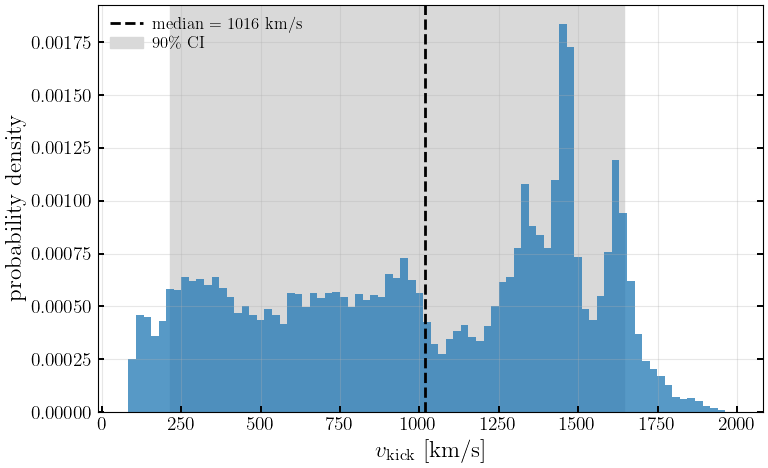

In [5]:
samples = flow.sample(q, a1, a2, theta1, theta2, 0.0, 0.0, n_samples=20000)

plt.figure(figsize=(8, 5))
plt.hist(samples[0], bins=80, density=True, alpha=0.75, color='C0')
plt.axvline(median, color='k', ls='--', lw=2, label=f'median = {median:.0f} km/s')
plt.axvspan(p5, p95, color='0.85', zorder=0, label=r'90\% CI')
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('probability density')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

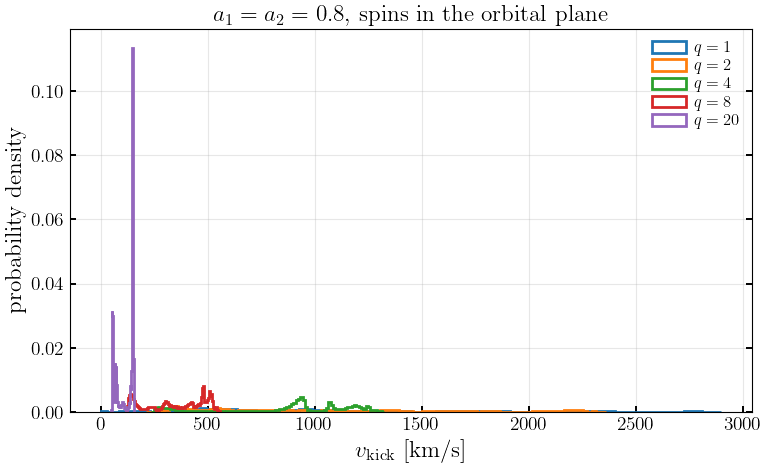

In [6]:
# Dependence on mass ratio at fixed spin magnitudes and tilts
q_cases = [1.0, 2.0, 4.0, 8.0, 20.0]

plt.figure(figsize=(8, 5))
for qc in q_cases:
    s = flow.sample(qc, 0.8, 0.8, np.pi / 2, np.pi / 2, 0.0, 0.0, n_samples=20000)
    plt.hist(s[0], bins=100, density=True, histtype='step', lw=2,
             label=rf'$q={qc:.0f}$')

plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('probability density')
plt.title(r'$a_1=a_2=0.8$, spins in the orbital plane')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

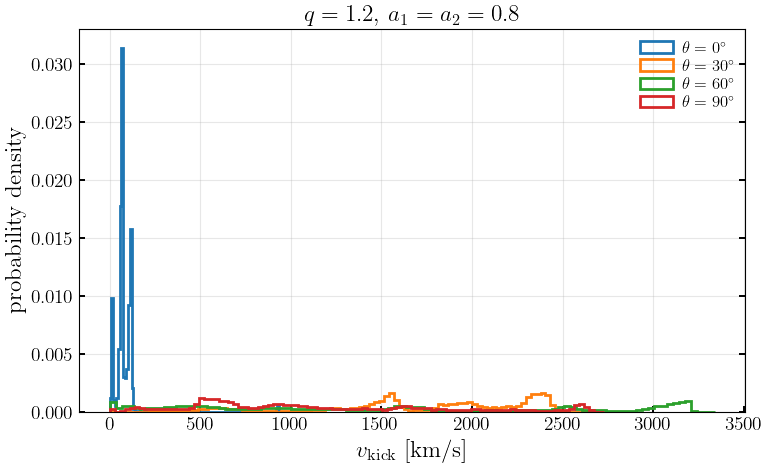

In [7]:
# Dependence on spin tilt: aligned spins give small recoils, in-plane
# spins give the superkick configurations
tilts = [0.0, np.pi / 6, np.pi / 3, np.pi / 2]

plt.figure(figsize=(8, 5))
for t in tilts:
    s = flow.sample(1.2, 0.8, 0.8, t, t, 0.0, 0.0, n_samples=20000)
    plt.hist(s[0], bins=100, density=True, histtype='step', lw=2,
             label=rf'$\theta = {np.degrees(t):.0f}^\circ$')

plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('probability density')
plt.title(r'$q=1.2$, $a_1=a_2=0.8$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Median and credible bands across parameter space

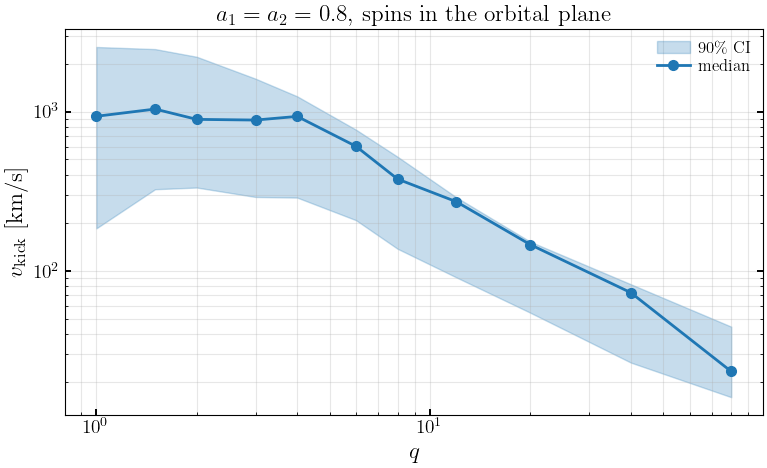

In [8]:
q_scan = np.array([1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 20.0, 40.0, 80.0])

med, lo, hi = [], [], []
for qc in q_scan:
    m, p5_, p95_ = flow.predict(qc, 0.8, 0.8, np.pi / 2, np.pi / 2, 0.0, 0.0,
                                n_samples=20000)
    med.append(m)
    lo.append(p5_)
    hi.append(p95_)

med = np.array(med)
lo = np.array(lo)
hi = np.array(hi)

plt.figure(figsize=(8, 5))
plt.fill_between(q_scan, lo, hi, alpha=0.25, color='C0', label=r'90\% CI')
plt.loglog(q_scan, med, 'o-', lw=2, ms=7, color='C0', label='median')
plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.title(r'$a_1=a_2=0.8$, spins in the orbital plane')
plt.legend(frameon=False)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

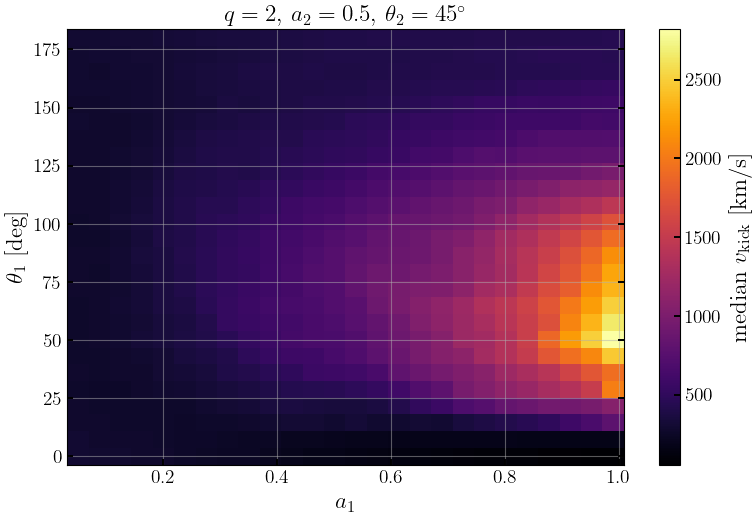

In [9]:
# Median recoil over the (a1, theta1) plane
a_g = np.linspace(0.05, 0.99, 26)
t_g = np.linspace(0.0, np.pi, 26)
A, T = np.meshgrid(a_g, t_g)

med_grid = flow.predict(2.0, A.ravel(), 0.5, T.ravel(), np.pi / 4, 0.0, 0.0,
                        n_samples=2000)[0].reshape(A.shape)

plt.figure(figsize=(8, 5.5))
im = plt.pcolormesh(A, np.degrees(T), med_grid, shading='auto', cmap='inferno')
cb = plt.colorbar(im)
cb.set_label(r'median $v_{\rm kick}$ [km/s]')
plt.xlabel('$a_1$')
plt.ylabel(r'$\theta_1$ [deg]')
plt.title(r'$q=2$, $a_2=0.5$, $\theta_2=45^\circ$')
plt.tight_layout()
plt.show()

### 4. Comparison with the earlier flow and with HLZ

`gwModel_kick_prec_flow` (Islam & Wadekar 2025) conditions only on $(q, a_1, a_2)$, marginalizing over all four angles. `gwModelRemP_flow` retains the richer context above, so it resolves the tilt dependence that the earlier model averages over.

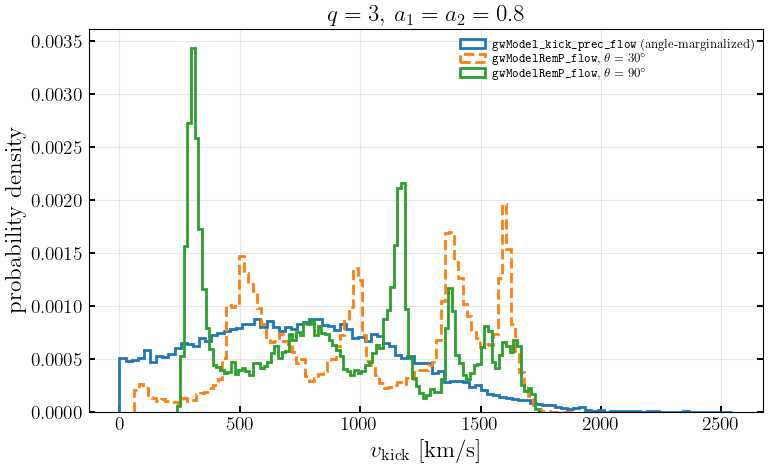

In [10]:
old_flow = gwModels.remnants.gwModel_kick_prec_flow('../gwModels/data/')

q_c, a1_c, a2_c = 3.0, 0.8, 0.8

plt.figure(figsize=(8, 5))
s_old = old_flow.sample(q=q_c, a1=a1_c, a2=a2_c, num_samples=20000)
plt.hist(s_old, bins=100, density=True, histtype='step', lw=2,
         label=r'\texttt{gwModel\_kick\_prec\_flow} (angle-marginalized)')

for t, ls in [(np.pi / 6, '--'), (np.pi / 2, '-')]:
    s_new = flow.sample(q_c, a1_c, a2_c, t, t, 0.0, 0.0, n_samples=20000)
    plt.hist(s_new[0], bins=100, density=True, histtype='step', lw=2, ls=ls,
             label=rf'\texttt{{gwModelRemP\_flow}}, $\theta={np.degrees(t):.0f}^\circ$')

plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('probability density')
plt.title(rf'$q={q_c:.0f}$, $a_1=a_2={a1_c}$')
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

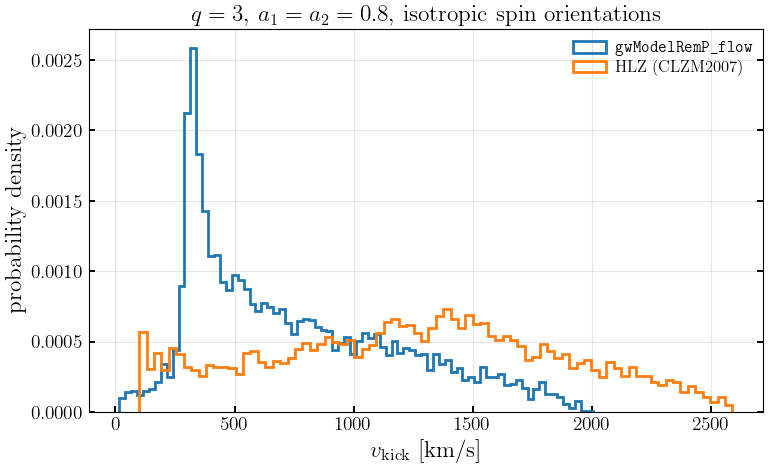

  flow  : median   642.0 km/s, 90th pct  1423.5
  HLZ   : median  1263.5 km/s, 90th pct  2077.6


In [11]:
# Against the deterministic HLZ precessing prescription, for an
# isotropic population of spin orientations at fixed magnitudes
rng = np.random.default_rng(0)
n_iso = 4000
q_i = 3.0
th1_i = np.arccos(rng.uniform(-1, 1, n_iso))
th2_i = np.arccos(rng.uniform(-1, 1, n_iso))
ph1_i = rng.uniform(0, 2 * np.pi, n_iso)
ph2_i = rng.uniform(0, 2 * np.pi, n_iso)

vk_flow = flow.sample(q_i, 0.8, 0.8, th1_i, th2_i, ph1_i, ph2_i, n_samples=1)[:, 0]

vk_hlz = np.array([
    gwModels.remnants.bbh_final_kick_precessing_CLZM2007(
        q=q_i, a1=0.8, a2=0.8, theta1=t1, theta2=t2,
        delta_phi=p1 - p2, Theta=0.0)
    for t1, t2, p1, p2 in zip(th1_i, th2_i, ph1_i, ph2_i)])

plt.figure(figsize=(8, 5))
plt.hist(vk_flow, bins=80, density=True, histtype='step', lw=2,
         label=r'\texttt{gwModelRemP\_flow}')
plt.hist(vk_hlz, bins=80, density=True, histtype='step', lw=2,
         label='HLZ (CLZM2007)')
plt.xlabel(r'$v_{\rm kick}$ [km/s]')
plt.ylabel('probability density')
plt.title(rf'$q={q_i:.0f}$, $a_1=a_2=0.8$, isotropic spin orientations')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'  flow  : median {np.median(vk_flow):7.1f} km/s, 90th pct {np.percentile(vk_flow, 90):7.1f}')
print(f'  HLZ   : median {np.median(vk_hlz):7.1f} km/s, 90th pct {np.percentile(vk_hlz, 90):7.1f}')

### 5. Consistency with the non-precessing limit

The flow was trained with 2000 synthetic non-precessing samples from `gwModelRemS` to anchor the aligned-spin boundary. At small tilt its median should track the deterministic aligned-spin recoil.

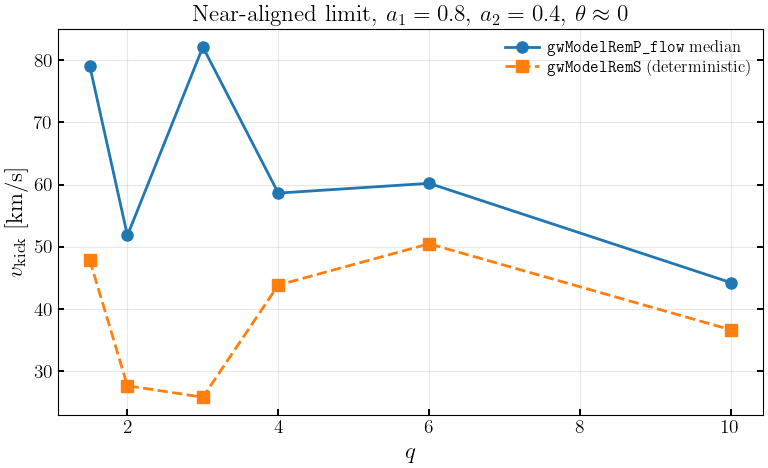

In [12]:
q_al = np.array([1.5, 2.0, 3.0, 4.0, 6.0, 10.0])
tiny = 0.01

med_al = flow.predict(q_al, 0.8, 0.4, tiny, tiny, 0.0, 0.0, n_samples=20000)[0]
vk_det = gwModels.remnants.gwModelRemS_kick(q_al, 0.8, 0.4)

plt.figure(figsize=(8, 5))
plt.plot(q_al, med_al, 'o-', lw=2, ms=8, label=r'\texttt{gwModelRemP\_flow} median')
plt.plot(q_al, vk_det, 's--', lw=2, ms=8, label=r'\texttt{gwModelRemS} (deterministic)')
plt.xlabel('$q$')
plt.ylabel(r'$v_{\rm kick}$ [km/s]')
plt.title(r'Near-aligned limit, $a_1=0.8$, $a_2=0.4$, $\theta \approx 0$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Timing

Unlike the analytic models, the flow cost is dominated by the neural network forward pass and scales with the number of samples drawn.

In [13]:
# Cost vs number of binaries, at a fixed number of samples each
sizes = [1, 10, 100, 1000, 5000]
means = []

for n in sizes:
    q_t = np.random.uniform(1, 10, n)
    a1_t = np.random.uniform(0, 1, n)
    a2_t = np.random.uniform(0, 1, n)
    t1_t = np.random.uniform(0, np.pi, n)
    t2_t = np.random.uniform(0, np.pi, n)
    reps = 5 if n <= 1000 else 3
    t = []
    for _ in range(reps):
        t0 = time.perf_counter()
        flow.sample(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0, n_samples=100)
        t.append(time.perf_counter() - t0)
    means.append(np.mean(t))

means = np.array(means)
print('100 samples per binary')
print(f'{'N':>8s}  {'time':>10s}  {'per binary':>13s}')
for n, m in zip(sizes, means):
    print(f'{n:>8d}  {m*1e3:8.2f} ms  {m/n*1e6:10.2f} us')

100 samples per binary
       N        time     per binary
       1      8.20 ms     8197.17 us
      10     14.32 ms     1432.50 us
     100     46.34 ms      463.41 us
    1000    299.45 ms      299.45 us
    5000   1338.80 ms      267.76 us


      100 samples :     3.61 ms
      500 samples :     8.03 ms
     1000 samples :    12.61 ms
     5000 samples :    28.96 ms
    20000 samples :    72.73 ms
   100000 samples :   299.48 ms


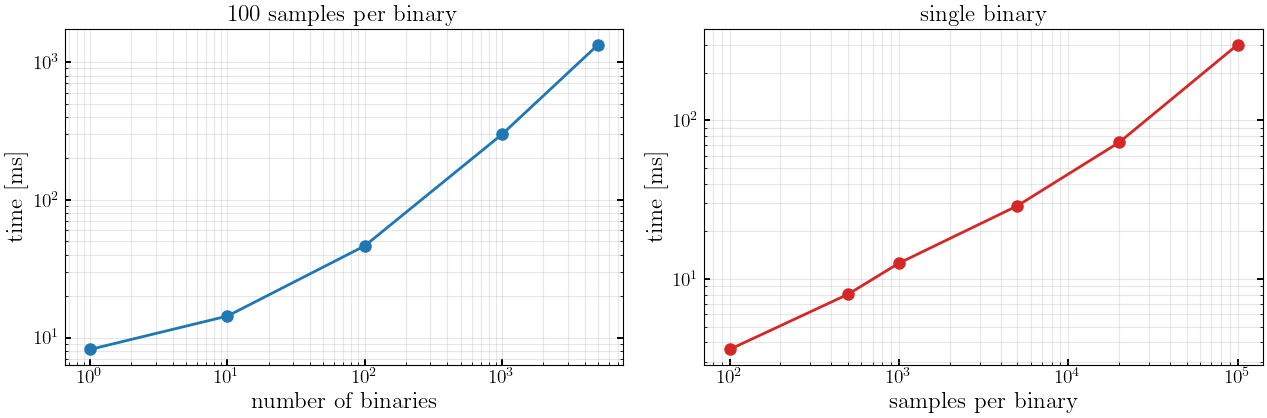

    20000 samples :    74.92 ms


   100000 samples :   303.53 ms


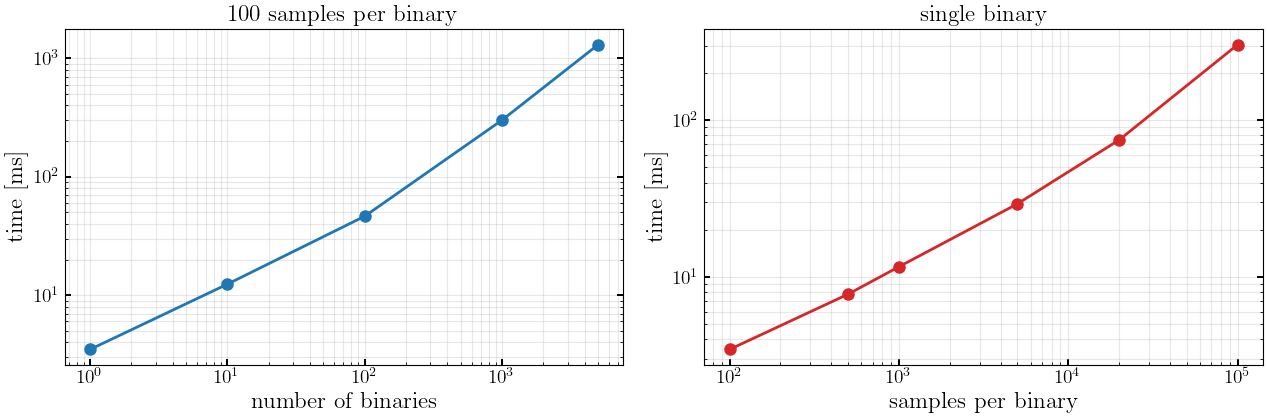

In [14]:
# Cost vs number of samples, for a single binary
ns_list = [100, 500, 1000, 5000, 20000, 100000]
tt = []
for ns in ns_list:
    t = []
    for _ in range(5):
        t0 = time.perf_counter()
        flow.sample(2.0, 0.7, 0.3, np.pi / 3, np.pi / 4, 0.0, 0.0, n_samples=ns)
        t.append(time.perf_counter() - t0)
    tt.append(np.mean(t))
    print(f'  {ns:>7d} samples : {np.mean(t)*1e3:8.2f} ms')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(sizes, means * 1e3, 'o-', lw=2, ms=8, color='C0')
axes[0].set_xlabel('number of binaries')
axes[0].set_ylabel('time [ms]')
axes[0].set_title('100 samples per binary')
axes[0].grid(alpha=0.3, which='both')

axes[1].loglog(ns_list, np.array(tt) * 1e3, 'o-', lw=2, ms=8, color='C3')
axes[1].set_xlabel('samples per binary')
axes[1].set_ylabel('time [ms]')
axes[1].set_title('single binary')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [15]:
# Analytic models vs the flow, same number of binaries
n = 2000
q_t = np.random.uniform(1, 10, n)
a1_t = np.random.uniform(0, 1, n)
a2_t = np.random.uniform(0, 1, n)
t1_t = np.random.uniform(0, np.pi, n)
t2_t = np.random.uniform(0, np.pi, n)
c1_t = a1_t * np.cos(t1_t)
c2_t = a2_t * np.cos(t2_t)

for name, fn in [
    ('gwModelRemS_kick (analytic)',
     lambda: gwModels.remnants.gwModelRemS_kick(q_t, c1_t, c2_t)),
    ('gwModelRemP_flow (100 samples)',
     lambda: flow.sample(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0, n_samples=100)),
]:
    t = []
    for _ in range(3):
        t0 = time.perf_counter()
        fn()
        t.append(time.perf_counter() - t0)
    print(f'  {name:>32s} : {np.mean(t)*1e3:9.2f} ms for {n} binaries')

       gwModelRemS_kick (analytic) :      0.20 ms for 2000 binaries
    gwModelRemP_flow (100 samples) :    570.45 ms for 2000 binaries


    gwModelRemP_flow (100 samples) :    564.15 ms for 2000 binaries
